# Social listening en YouTube
### Detección de tendencias de noticias emergentes con NLP

**Contexto breve**
- Objetivo: identificar qué temas de noticias ganan conversación con el tiempo, a partir de comentarios de YouTube en un conjunto fijo de canales/videos semilla.
- Enfoque: capa gratuita de la YouTube Data API (lecturas baratas, búsquedas caras), preprocesamiento de texto coloquial, vectorización TF-IDF, modelado de tópicos con NMF y seguimiento del peso de cada tema en el tiempo.
- **Este notebook nunca incluye una API key**. La celda de extracción real está comentada y muestra cómo cargar la credencial desde una variable de entorno; el resto del notebook trabaja sobre un **dataset sintético de comentarios**, construido para demostrar el pipeline sin depender de la API en tiempo de ejecución.
- Alcance: este es un punto de partida para entender el método, no un estudio exhaustivo. Un análisis más completo necesitaría más categorías, más canales y una ventana de tiempo más larga.
- Artículo completo, con el diagrama interactivo y los casos de uso adicionales: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/social-listening-youtube-tendencias-noticias-nlp/


## 0. Pipeline de la solución

- **Fuentes**: canales/videos semilla + capa gratuita de la YouTube Data API (10,000 unidades/día)
- **Extracción**: lectura de comentarios (1 unidad de cuota por página), evitando `search.list` (100 unidades por búsqueda)
- **Credencial**: variable de entorno, nunca escrita en el notebook
- **Preprocesamiento**: limpieza adaptada al lenguaje coloquial del comentario
- **Vectorización**: TF-IDF
- **Modelado de tópicos**: NMF (factorización de matrices no negativas)
- **Seguimiento temporal**: peso de cada tema por ventana de tiempo, para detectar cuáles crecen de forma sostenida

El diagrama interactivo completo está disponible en el artículo enlazado arriba.

```python
# Referencia de cómo se leerían comentarios reales (no se ejecuta en este notebook):
#
# import os
# from googleapiclient.discovery import build
#
# API_KEY = os.environ["YOUTUBE_API_KEY"]  # nunca se escribe la key en el notebook
# youtube = build("youtube", "v3", developerKey=API_KEY)
#
# response = youtube.commentThreads().list(
#     part="snippet", videoId="VIDEO_ID_SEMILLA", maxResults=100
# ).execute()
```


## 1. Carga de datos

- Dataset sintético: `outputs/comentarios_youtube_sintetico.csv`
- Comentarios sintéticos generados por plantilla, distribuidos en 4 categorías temáticas y 70 semanas
- Una de las categorías crece de forma sostenida en el último tercio del periodo, simulando un tema emergente


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/comentarios_youtube_sintetico.csv')
dataset['fecha'] = pd.to_datetime(dataset['fecha'])

print(f'El dataset (sintético) tiene {dataset.shape[0]} comentarios entre {dataset["fecha"].min().date()} y {dataset["fecha"].max().date()}.')
dataset.head(3)


El dataset (sintético) tiene 3991 comentarios entre 2024-10-07 y 2026-02-08.


,comment_id,video_seed_id,fecha,categoria_real,comentario,likes
0,c000042,seed_dep_5,2024-10-07,Deportes,este canal explico arbitro mejor que cualquier...,1
1,c000040,seed_dep_4,2024-10-07,Deportes,este canal explico arbitro mejor que cualquier...,2
2,c000015,seed_eco_1,2024-10-07,Economia,este canal explico inflacion mejor que cualqui...,2


## 2. Explicación de los datos

- `comentario`: texto del comentario (sintético, generado por plantilla)
- `categoria_real`: etiqueta de referencia usada solo para validar que el modelado de tópicos encuentra una estructura razonable, no se usa como input del modelo
- `fecha`: fecha del comentario, base para el seguimiento temporal
- `likes`: interacciones del comentario (no se usa en el modelado de tópicos, queda disponible para análisis futuros)


In [2]:
dataset['categoria_real'].value_counts()


categoria_real
Entretenimiento    1166
Deportes           1027
Economia            905
Clima y Energia     893
Name: count, dtype: int64

## 3. Análisis exploratorio (EDA)

- Volumen de comentarios por semana, para tener una primera idea visual de qué categoría crece con el tiempo antes de aplicar cualquier modelo


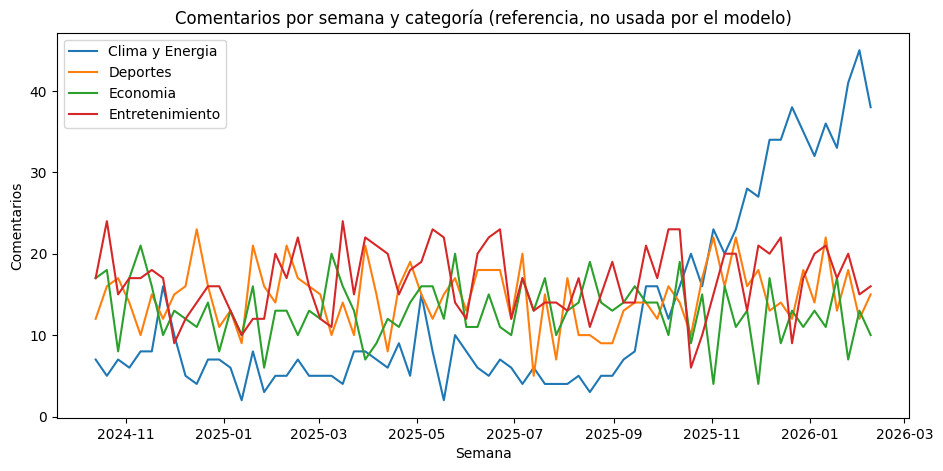

In [3]:
import matplotlib.pyplot as plt

semanal = dataset.groupby([pd.Grouper(key='fecha', freq='W'), 'categoria_real']).size().unstack(fill_value=0)

plt.figure(figsize=(11, 5))
for cat in semanal.columns:
    plt.plot(semanal.index, semanal[cat], label=cat)
plt.title('Comentarios por semana y categoría (referencia, no usada por el modelo)')
plt.xlabel('Semana')
plt.ylabel('Comentarios')
plt.legend()
plt.show()


## 4. Modelado

- Preprocesamiento ligero del texto coloquial (minúsculas, remoción de acentos y signos)
- Vectorización TF-IDF sobre el texto ya limpio
- Modelado de tópicos con NMF, sin usar la etiqueta `categoria_real` en ningún momento


In [4]:
import re
import unicodedata

def limpiar_comentario(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

dataset['comentario_limpio'] = dataset['comentario'].apply(limpiar_comentario)
dataset[['comentario', 'comentario_limpio']].head(3)


,comentario,comentario_limpio
0,este canal explico arbitro mejor que cualquier...,este canal explico arbitro mejor que cualquier...
1,este canal explico arbitro mejor que cualquier...,este canal explico arbitro mejor que cualquier...
2,este canal explico inflacion mejor que cualqui...,este canal explico inflacion mejor que cualqui...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

stopwords_es = [
    'a', 'afectada', 'alguien', 'analisis', 'cada', 'canal', 'con', 'creer', 'creo',
    'cualquier', 'cubrir', 'de', 'deberian', 'dias', 'el', 'en', 'es', 'escucho', 'esta',
    'este', 'explica', 'explico', 'familia', 'gracias', 'grandes', 'habla', 'hablando',
    'hacer', 'interesante', 'la', 'largo', 'las', 'llevo', 'lo', 'los', 'mas', 'me',
    'medios', 'mejor', 'mencionaron', 'menos', 'mes', 'mi', 'nadie', 'no', 'noticias',
    'noticiero', 'otra', 'para', 'parte', 'paso', 'peor', 'poner', 'por', 'porque',
    'primera', 'proximo', 'puedo', 'que', 'se', 'segunda', 'sobre', 'tambien', 'tema',
    'tendencias', 'todos', 'tradicionales', 'una', 'va', 'van', 'vez', 'videos', 'viendo',
    'vio', 'y', 'yo',
]

# Filtra explícitamente las palabras "pegamento" de la plantilla del comentario, para que
# NMF encuentre estructura en las palabras clave de cada tema y no en la redacción genérica.
vectorizer = TfidfVectorizer(max_features=300, min_df=5, stop_words=stopwords_es)
X_tfidf = vectorizer.fit_transform(dataset['comentario_limpio'])

n_topics = 4
nmf = NMF(n_components=n_topics, random_state=42, max_iter=400)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_

feature_names = vectorizer.get_feature_names_out()
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[:-9:-1]]
    print(f'Tema {i}: {", ".join(top_words)}')


Tema 0: actriz, streaming, actor, estreno, director, concierto, temporada, festival
Tema 1: portero, jugador, transferencia, gol, lesion, estadio, seleccion, medalla
Tema 2: credito, salario, ahorro, gasolina, deuda, desempleo, precios, inflacion
Tema 3: calor, apagon, clima, incendio, tormenta, inundacion, sequia, temperatura


## 5. Evaluación

- Peso promedio de cada tema por ventana de tiempo (mensual)
- Un tema se marca como emergente si su peso crece de forma sostenida entre el primer y el último tramo del periodo, no solo si tiene mayor volumen total


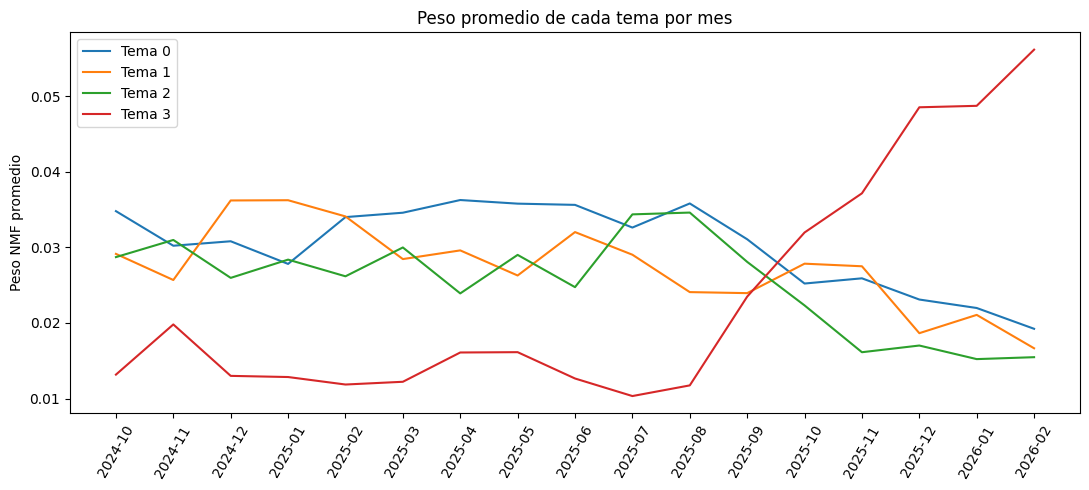

In [6]:
dataset['tema_dominante'] = W.argmax(axis=1)
for i in range(n_topics):
    dataset[f'peso_tema_{i}'] = W[:, i]

dataset['mes'] = dataset['fecha'].dt.to_period('M')
pesos_mensuales = dataset.groupby('mes')[[f'peso_tema_{i}' for i in range(n_topics)]].mean()

plt.figure(figsize=(11, 5))
for i in range(n_topics):
    plt.plot(pesos_mensuales.index.astype(str), pesos_mensuales[f'peso_tema_{i}'], label=f'Tema {i}')
plt.xticks(rotation=60)
plt.title('Peso promedio de cada tema por mes')
plt.ylabel('Peso NMF promedio')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
temas_emergentes = []
for i in range(n_topics):
    serie = pesos_mensuales[f'peso_tema_{i}']
    crecimiento = serie.iloc[-3:].mean() / max(serie.iloc[:3].mean(), 1e-6)
    if crecimiento > 1.15:
        temas_emergentes.append((i, round(crecimiento, 2)))

print('Temas marcados como emergentes (crecimiento > 30% entre el inicio y el final del periodo):')
for tema, crecimiento in temas_emergentes:
    palabras = [feature_names[j] for j in H[tema].argsort()[:-9:-1]]
    print(f'  Tema {tema} (x{crecimiento}): {", ".join(palabras)}')


Temas marcados como emergentes (crecimiento > 30% entre el inicio y el final del periodo):
  Tema 3 (x3.34): calor, apagon, clima, incendio, tormenta, inundacion, sequia, temperatura


## Hallazgos principales

- Diseñar el pipeline alrededor del costo real de cada llamada a la API (leer es barato, buscar es caro) fue una decisión tan importante como el modelo de tópicos elegido.
- El modelado de tópicos con NMF, sin usar ninguna etiqueta de categoría, logra recuperar una estructura temática razonable a partir de comentarios cortos e informales.
- El seguimiento del peso de cada tema por ventana de tiempo permite distinguir un tema que gana tracción de forma sostenida de uno que solo tuvo un pico de volumen puntual.
- Este es un buen punto de partida para entender el método, no un sistema de monitoreo exhaustivo: un estudio más completo necesitaría más categorías, más canales semilla y un horizonte de tiempo más largo.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/social-listening-youtube-tendencias-noticias-nlp/
